<a href="https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-08/08-01-CNN-2D-Convolution-Sliding-Visualization.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Visualize how a 3×3 convolutional filter slides across a 5×5 image and builds a feature map one value at a time. This notebook demonstrates the current image patch, the filter, element-wise multiplication, output accumulation, stride, zero padding, output-size changes, and verification against PyTorch’s F.conv2d implementation.

Top-left 3×3 patch:
 tensor([[1., 2., 0.],
        [4., 5., 2.],
        [7., 8., 1.]])

Filter:
 tensor([[ 1.,  0., -1.],
        [ 1.,  0., -1.],
        [ 1.,  0., -1.]])

Element-wise product:
 tensor([[ 1.,  0., -0.],
        [ 4.,  0., -2.],
        [ 7.,  0., -1.]])

Row sums:
  row 0: +1 +0 -0 -> +1
  row 1: +4 +0 -2 -> +2
  row 2: +7 +0 -1 -> +6

Total sum: 9.0


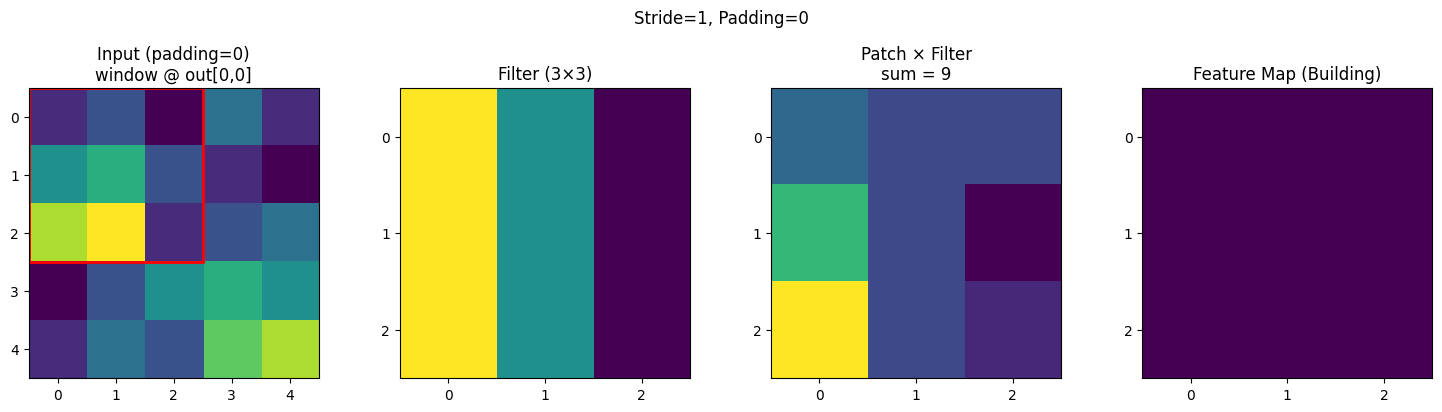


=== Final output (manual), padding=0 ===
tensor([[ 9.,  9., -1.],
        [ 4.,  7.,  0.],
        [ 1.,  0., -7.]])

=== Final output (PyTorch conv2d), padding=0 ===
tensor([[ 9.,  9., -1.],
        [ 4.,  7.,  0.],
        [ 1.,  0., -7.]])

Max absolute difference: 0.0


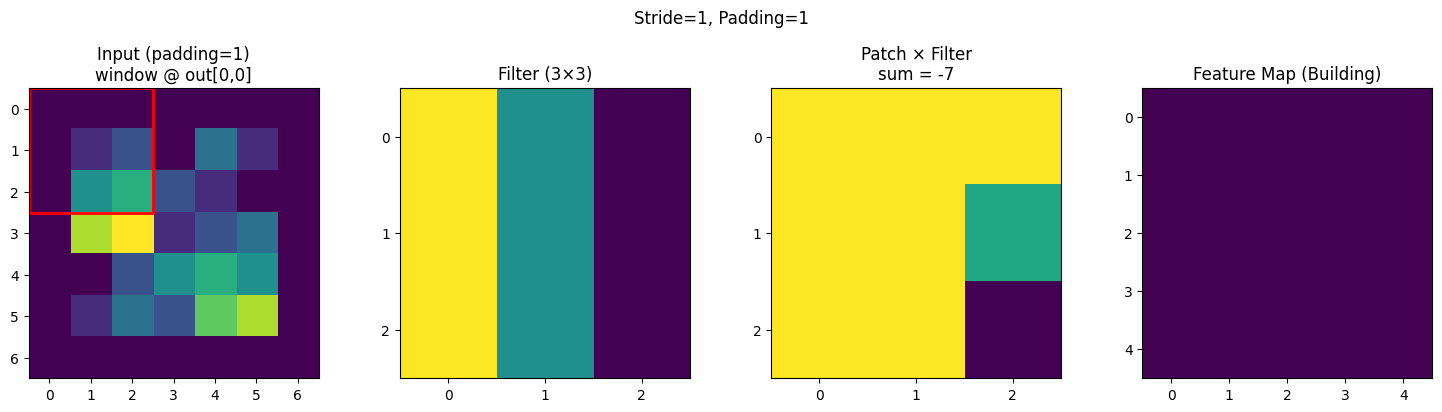


=== Final output (manual), padding=1 ===
tensor([[ -7.,   3.,   3.,   1.,   4.],
        [-15.,   9.,   9.,  -1.,   6.],
        [-15.,   4.,   7.,   0.,   8.],
        [-13.,   1.,   0.,  -7.,  13.],
        [ -5.,  -5.,  -6.,  -5.,  11.]])

=== Final output (PyTorch conv2d), padding=1 ===
tensor([[ -7.,   3.,   3.,   1.,   4.],
        [-15.,   9.,   9.,  -1.,   6.],
        [-15.,   4.,   7.,   0.,   8.],
        [-13.,   1.,   0.,  -7.,  13.],
        [ -5.,  -5.,  -6.,  -5.,  11.]])

Max absolute difference: 0.0


In [5]:

# Visualize 2D convolution sliding
#
# Goal:
# This code shows how a 3×3 CNN filter slides across a 5×5 image and builds
# a feature map one value at a time.
#
# It displays:
# 1. The input image and the current 3×3 patch being examined
# 2. The 3×3 filter
# 3. The element-wise multiplication between the patch and filter
# 4. The feature map as it is being filled
#
# The same example runs twice:
# - No padding: output feature map is 3×3
# - Padding = 1: output feature map is 5×5
#
# Note:
# PyTorch's F.conv2d performs cross-correlation, not mathematically flipped
# convolution. In deep learning, this operation is still commonly called convolution.

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# Example image: 5×5 grayscale image
image = torch.tensor([
    [1., 2., 0., 3., 1.],
    [4., 5., 2., 1., 0.],
    [7., 8., 1., 2., 3.],
    [0., 2., 4., 5., 4.],
    [1., 3., 2., 6., 7.],
])

# Example filter: 3×3 kernel
kernel = torch.tensor([
    [1., 0., -1.],
    [1., 0., -1.],
    [1., 0., -1.],
])


def conv2d_manual_slide(x2d, k2d, stride=1, padding=0, pause=0.7, cmap="viridis"):
    """
    Visualize a manual sliding-window convolution for a single-channel 2D input.

    x2d: input image of shape (H, W)
    k2d: filter/kernel of shape (KH, KW)
    stride: number of pixels the filter moves at each step
    padding: number of zero-border pixels added around the input
    pause: delay between visualization steps
    cmap: color map used for visualization
    """
    assert x2d.ndim == 2 and k2d.ndim == 2

    H, W = x2d.shape
    KH, KW = k2d.shape

    # Add zero padding around the input image.
    x_pad = F.pad(
        x2d.unsqueeze(0).unsqueeze(0),
        (padding, padding, padding, padding),
        mode="constant",
        value=0.0
    ).squeeze(0).squeeze(0)

    Hp, Wp = x_pad.shape

    # Compute output feature map height and width.
    # // means integer division; the number of valid filter positions must be whole.
    out_h = (Hp - KH) // stride + 1
    out_w = (Wp - KW) // stride + 1

    # Start with an empty feature map.
    out = torch.full((out_h, out_w), float("nan"))

    # PyTorch reference output to verify our manual calculation.
    y_ref = F.conv2d(
        x2d.unsqueeze(0).unsqueeze(0),
        k2d.unsqueeze(0).unsqueeze(0),
        stride=stride,
        padding=padding
    ).squeeze()

    plt.ion()
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

    # Slide the filter from left to right, then top to bottom.
    for oy in range(out_h):
        for ox in range(out_w):
            y0 = oy * stride
            x0 = ox * stride

            # Select the current image patch.
            patch = x_pad[y0:y0 + KH, x0:x0 + KW]

            # Multiply patch and filter element by element.
            prod = patch * k2d

            # Sum the products to produce one feature-map value.
            s = prod.sum()
            out[oy, ox] = s

            # Panel 1: input image with current patch highlighted.
            axes[0].clear()
            axes[0].imshow(x_pad.numpy(), cmap=cmap)
            axes[0].add_patch(
                Rectangle(
                    (x0 - 0.5, y0 - 0.5),
                    KW,
                    KH,
                    fill=False,
                    edgecolor="red",
                    linewidth=2
                )
            )
            axes[0].set_title(f"Input (padding={padding})\nwindow @ out[{oy},{ox}]")
            axes[0].set_xticks(range(Wp))
            axes[0].set_yticks(range(Hp))

            # Panel 2: filter/kernel.
            axes[1].clear()
            axes[1].imshow(k2d.numpy(), cmap=cmap)
            axes[1].set_title("Filter (3×3)")
            axes[1].set_xticks(range(KW))
            axes[1].set_yticks(range(KH))

            # Panel 3: element-wise multiplication result.
            axes[2].clear()
            axes[2].imshow(prod.numpy(), cmap=cmap)
            axes[2].set_title(f"Patch × Filter\nsum = {s.item():.0f}")
            axes[2].set_xticks(range(KW))
            axes[2].set_yticks(range(KH))

            # Panel 4: feature map as it is being built.
            axes[3].clear()

            # Replace NaN values for display only so the plot can render.
            # These NaN values represent feature-map positions that have not
            # yet been computed.

            disp = out.clone()
            nan_mask = torch.isnan(disp)

            if (~nan_mask).any():
                mn = disp[~nan_mask].min().item()
                disp[nan_mask] = mn
            else:
                disp[nan_mask] = 0.0

            axes[3].imshow(disp.numpy(), cmap=cmap)
            axes[3].set_title("Feature Map (Building)")
            axes[3].set_xticks(range(out_w))
            axes[3].set_yticks(range(out_h))

            fig.suptitle(f"Stride={stride}, Padding={padding}", y=1.02, fontsize=12)
            fig.tight_layout()
            plt.pause(pause)

    plt.ioff()
    plt.show()

    # Print final manual output and compare with PyTorch output.
    print(f"\n=== Final output (manual), padding={padding} ===")
    print(out)

    print(f"\n=== Final output (PyTorch conv2d), padding={padding} ===")
    print(y_ref)

    print("\nMax absolute difference:", (out - y_ref).abs().max().item())


def print_top_left_demo(x2d, k2d):
    """
    Print the arithmetic for the top-left 3×3 region with no padding.
    This verifies the first convolution result.
    """
    patch = x2d[:3, :3]
    prod = patch * k2d

    print("Top-left 3×3 patch:\n", patch)
    print("\nFilter:\n", k2d)
    print("\nElement-wise product:\n", prod)

    print("\nRow sums:")
    for r in range(3):
        a, b, c = prod[r].tolist()
        print(f"  row {r}: {a:+.0f} {b:+.0f} {c:+.0f} -> {a + b + c:+.0f}")

    print("\nTotal sum:", prod.sum().item())


# 1. Verify the top-left convolution arithmetic.
print_top_left_demo(image, kernel)

# 2. Visualize convolution with no padding.
# A 5×5 image with a 3×3 filter produces a 3×3 feature map.
conv2d_manual_slide(image, kernel, stride=1, padding=0, pause=0.75)

# 3. Visualize convolution with padding = 1.
# Padding turns the 5×5 input into a 7×7 padded input internally,
# allowing the 3×3 filter to produce a 5×5 feature map.
conv2d_manual_slide(image, kernel, stride=1, padding=1, pause=0.45)
